# YOLO Distillation Example using Florence 2

## Install libraries

In [ ]:
!pip install -q "transformers==4.44.2" "peft==0.13.2" accelerate
!pip install -q autodistill supervision roboflow timm einops Pillow tqdms
!pip install -q autodistill-florence-2 --no-deps
!pip install -q autodistill_yolov8 supervision roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 117.6 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 0.12.0 Requires-Python >=3.8,<3.12.0; 0.13.0 Requires-Python >=3.8,<3.12.0; 0.13.0rc3 Requires-Python >=3.8,<3.12.0; 0.13.0rc4 Requires-Python >=3.8,<3.12.0; 0.14.0 Requires-Python >=3.8,<3.12.0; 0.14.0b1 Requires-Python >=3.8,<3.12.0; 0.14.0b2 Requires-Python >=3.8,<3.12.0; 0.15.0 Requires-Python >=3.8,<3.12.0; 0.15.0rc1 Requires-Python >=3.8,<3.12.0; 0.15.0rc2 Requires-Python >=3.8,<3.12.0; 0.15.0rc3 Requires-Python >=3.8,<3.12.0; 0.15.0rc4 Requires-Python >=3.8,<3.12.0; 0.16.0 Requires-Python >=3.8,<3.12.0; 0.16.0r

In [ ]:
from unittest.mock import patch
from transformers.dynamic_module_utils import get_imports

def fixed_get_imports(filename):
    imports = get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports

## Annotate Dataset using Teacher (Base) Model

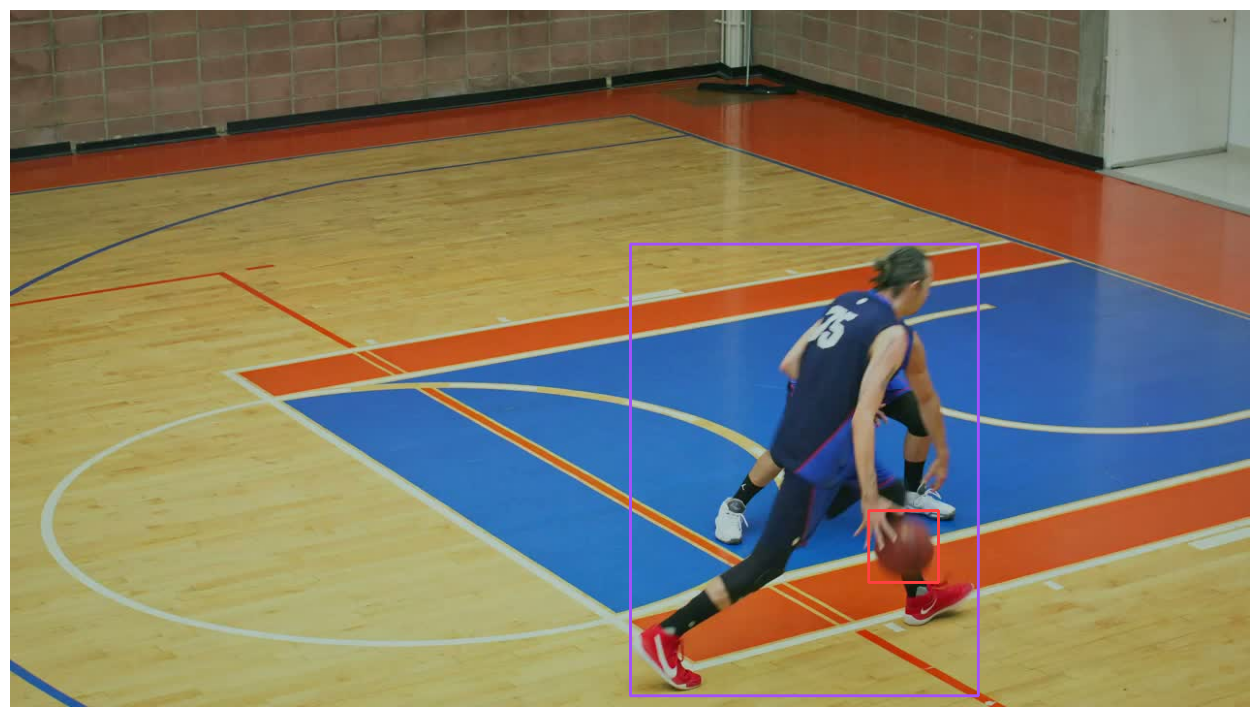

Labeling images: 0it [00:00, ?it/s]

Labeled dataset created - ready for distillation.


In [ ]:
from autodistill_florence_2 import Florence2
from autodistill.detection import CaptionOntology
from PIL import Image
import supervision as sv

ontology = CaptionOntology({
    "basketball player": "player",
    "basketball": "basketball"
})

with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):
    base_model = Florence2(ontology=ontology)


# First test on one image if ontology is correct
image = Image.open("/content/images/0001.jpg")
result = base_model.predict('/content/images/0001.jpg')

detections = result[0] if isinstance(result, list) else result

bounding_box_annotator = sv.BoxAnnotator()
annotated_frame = bounding_box_annotator.annotate(
    scene=image.copy(),
    detections=detections
)
sv.plot_image(image=annotated_frame, size=(16, 16))

# label a dataset
base_model.label("./context_images", extension=".jpg")

In [ ]:
# Label the complete dataset
dataset = base_model.label(
    input_folder="./images",
    output_folder="./dataset",
    extension=".jpg"
)

Labeling ./images/0003.jpg: 100%|██████████| 100/100 [01:30<00:00,  1.11it/s]


Labeled dataset created - ready for distillation.


## Train the Student (Target) model

In [ ]:
# Use this only for trusted checkpoints like official yolov8n.pt.
import torch

_original_torch_load = torch.load

def torch_load_compat(*args, **kwargs):
    kwargs["weights_only"] = False
    return _original_torch_load(*args, **kwargs)

torch.load = torch_load_compat

In [ ]:
from autodistill_yolov8 import YOLOv8

target_model = YOLOv8("yolov8n.pt")
target_model.train( "./dataset/data.yaml", epochs=50 )

100%|██████████| 6.23M/6.23M [00:00<00:00, 78.3MB/s]
New https://pypi.org/project/ultralytics/8.4.69 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU
yolo/engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=./dataset/data.yaml, epochs=50, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False,

wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
optimizer: SGD(lr=0.01) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias
train: Scanning /content/dataset/train/labels... 80 images, 0 backgrounds, 0 corrupt: 100%|██████████| 80/80 [00:00<00:00, 1836.50it/s]
train: New cache created: /content/dataset/train/labels.cache
Argument(s) 'quality_lower' are not valid for transform ImageCompression
Got processor for bboxes, but no transform to process it.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Scanning /content/dataset/valid/labels... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<00:00, 1728.97it/s]
val: New cache created: /content/dataset/valid/labels.cache
Plotting labels to runs/detect/train/labels.jpg...

## Test model inference

In [ ]:
import cv2
import yaml
import supervision as sv
from pathlib import Path

# image to test
image_path = "/content/test_image.png"

# Run prediction
pred = target_model.predict(image_path, confidence=0.25)

result = pred[0] if isinstance(pred, list) else pred

print("Result type:", type(result))
print(result)

# Convert Ultralytics Results -> Supervision Detections
try:
    detections = sv.Detections.from_ultralytics(result)
except:
    boxes = result.boxes

    xyxy = boxes.xyxy.cpu().numpy()
    confidence = boxes.conf.cpu().numpy()
    class_id = boxes.cls.cpu().numpy().astype(int)

    detections = sv.Detections(
        xyxy=xyxy,
        confidence=confidence,
        class_id=class_id
    )

print("Detections type:", type(detections))
print("Number of detections:", len(detections))
print(detections)


image 1/1 /content/test_image.png: 416x640 2 players, 1 basketball, 129.8ms
Speed: 1.7ms preprocess, 129.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


Result type: <class 'ultralytics.yolo.engine.results.Results'>
ultralytics.yolo.engine.results.Results object with attributes:

boxes: ultralytics.yolo.engine.results.Boxes object
keypoints: None
keys: ['boxes']
masks: None
names: {0: 'player', 1: 'basketball'}
orig_img: array([[[104, 115,  95],
        [ 95, 106,  86],
        [ 85,  96,  77],
        ...,
        [ 93,  92,  79],
        [ 94,  93,  80],
        [ 94,  93,  80]],

       [[103, 115,  95],
        [ 94, 105,  86],
        [ 84,  96,  76],
        ...,
        [105, 103,  90],
        [104, 102,  89],
        [103, 101,  88]],

       [[103, 115,  95],
        [ 94, 106,  86],
        [ 84,  96,  77],
        ...,
        [110, 108,  94],
        [109, 106,  93],
        [107, 105,  91]],

       ...,

       [[143,  75,  28],
        [143,  75,  29],
        [144,  76,  30],
        ...,
        [ 49, 122, 161],
        [ 49, 121, 160],
        [ 50, 122, 161]],

       [[143,  74,  28],
        [144,  75,  29],
     

['player 0.86', 'basketball 0.85', 'player 0.30']


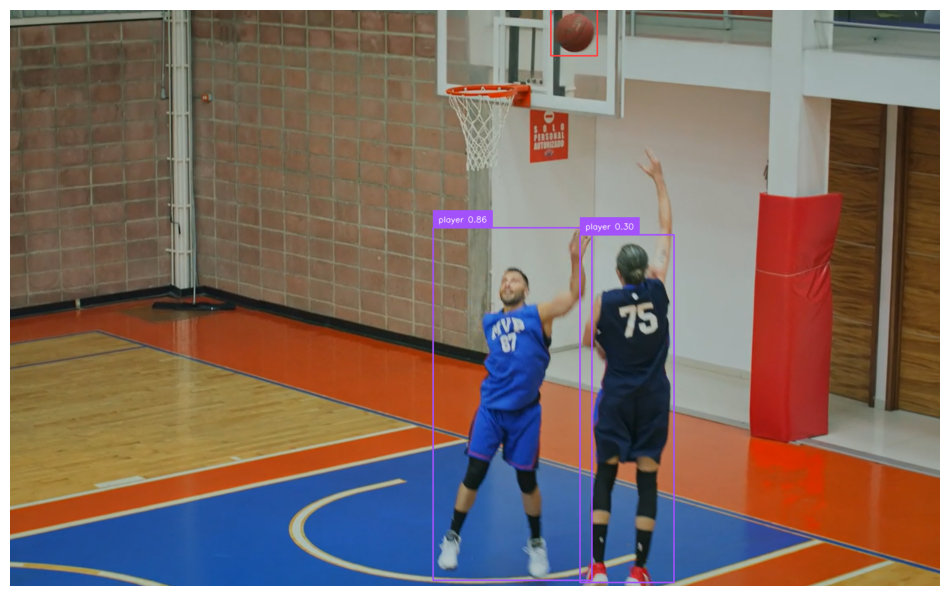

In [ ]:
# Load class names
with open("/content/dataset/data.yaml", "r") as f:
    data = yaml.safe_load(f)

CLASS_NAMES = data["names"]

image = cv2.imread(image_path)
#image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

labels = [
    f"{CLASS_NAMES[int(class_id)]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

print(labels)

box_annotator = sv.BoxAnnotator()

annotated_image = box_annotator.annotate(
    scene=image.copy(),
    detections=detections
)

if hasattr(sv, "LabelAnnotator"):
    label_annotator = sv.LabelAnnotator()
    annotated_image = label_annotator.annotate(
        scene=annotated_image,
        detections=detections,
        labels=labels
    )
else:
    annotated_image = box_annotator.annotate(
        scene=image.copy(),
        detections=detections,
        labels=labels
    )

sv.plot_image(annotated_image, size=(12, 8))

## Configure project and test dataset before upload

In [ ]:
from roboflow import Roboflow
from pathlib import Path
from getpass import getpass
import yaml
import json

ROBOFLOW_API_KEY = getpass("Enter Roboflow API key: ")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("tim-4ijf0")
project = workspace.project("basketball-chjzf")

dataset_dir = Path("/content/dataset")

# Read class names from data.yaml
with open(dataset_dir / "data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml["names"]

if isinstance(names, dict):
    labelmap = {str(k): v for k, v in names.items()}
else:
    labelmap = {str(i): name for i, name in enumerate(names)}

labelmap_path = dataset_dir / "labelmap.json"

with open(labelmap_path, "w") as f:
    json.dump(labelmap, f)

print("Label map:", labelmap)
print("Saved labelmap to:", labelmap_path)

Enter Roboflow API key: ··········
loading Roboflow workspace...
loading Roboflow project...
Label map: {'0': 'player', '1': 'basketball'}
Saved labelmap to: /content/dataset/labelmap.json


In [ ]:
pred = target_model.predict(
    "/content/dataset/valid/images/0015.jpg",
    confidence=0.25
)

result = pred[0] if isinstance(pred, list) else pred

CLASS_NAMES = ["player", "basketball"]

if result.boxes is not None and len(result.boxes) > 0:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = CLASS_NAMES[class_id]

        print(f"Found: {class_name} with confidence {confidence:.2f}")
else:
    print("No object found")


image 1/1 /content/dataset/valid/images/0015.jpg: 384x640 1 player, 1 basketball, 284.1ms
Speed: 6.4ms preprocess, 284.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


Found: player with confidence 0.94
Found: basketball with confidence 0.83


In [ ]:
from pathlib import Path
from collections import Counter
import yaml

dataset_dir = Path("/content/dataset")

with open(dataset_dir / "data.yaml", "r") as f:
    data = yaml.safe_load(f)

print(data)

names = data["names"]
print("Class names:", names)

counter = Counter()

for label_file in dataset_dir.glob("**/labels/*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            if line.strip():
                class_id = line.split()[0]
                counter[class_id] += 1

print("Class counts:", counter)

{'names': ['player', 'basketball'], 'nc': 2, 'train': '/content/dataset/train/images', 'val': '/content/dataset/valid/images'}
Class names: ['player', 'basketball']
Class counts: Counter({'0': 111, '1': 100})


## Upload dataset to Roboflow Project

In [ ]:
# Final code to upload dataset to Roboflow Project
from pathlib import Path

image_extensions = [".jpg", ".jpeg", ".png"]

# Use integer keys
labelmap = {0: "player", 1: "basketball"}

for split in ["train", "valid", "test"]:
    image_dir = dataset_dir / split / "images"
    label_dir = dataset_dir / split / "labels"

    if not image_dir.exists():
        print(f"Skipping {split}: no images folder")
        continue

    image_paths = []

    for ext in image_extensions:
        image_paths.extend(list(image_dir.glob(f"*{ext}")))

    print(f"Uploading {len(image_paths)} images from {split}...")

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"

        if label_path.exists():
            result = project.single_upload(
                image_path=str(image_path),
                annotation_path=str(label_path),
                annotation_labelmap=labelmap,
                split=split,
                batch_name="autodistill-florence2-basketball",
                is_prediction=False,
                annotation_overwrite=True
            )
        else:
            result = project.single_upload(
                image_path=str(image_path),
                split=split,
                batch_name="autodistill-florence2-basketball"
            )

        print(image_path.name, result)

Uploading 80 images from train...
0095.jpg {'image': {'success': True, 'id': '1MUdCTp5ZlrrA3SGAvD8'}, 'annotation': {'success': True}, 'upload_time': 0.8545515537261963, 'annotation_time': 0.461322546005249, 'upload_retry_attempts': 0, 'annotation_upload_retry_attempts': 0}
0059.jpg {'image': {'success': True, 'id': 'PQFOXUQmoyDku21HcSx4'}, 'annotation': {'success': True}, 'upload_time': 0.6065833568572998, 'annotation_time': 0.49465346336364746, 'upload_retry_attempts': 0, 'annotation_upload_retry_attempts': 0}
0023.jpg {'image': {'success': True, 'id': 'asH0GPVGNvTaS3laRgKo'}, 'annotation': {'success': True}, 'upload_time': 0.5417890548706055, 'annotation_time': 0.33838748931884766, 'upload_retry_attempts': 0, 'annotation_upload_retry_attempts': 0}
0058.jpg {'image': {'success': True, 'id': 'L3OdXGK637MDo0MzXCMk'}, 'annotation': {'success': True}, 'upload_time': 0.3909623622894287, 'annotation_time': 0.41581201553344727, 'upload_retry_attempts': 0, 'annotation_upload_retry_attempts':